<a href="https://colab.research.google.com/github/Nasyaril/UTS_Citra_Digital/blob/main/PCD_No01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_9414/2746056468.py:39: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 0].hist(f.ravel(), 256, [0, 256], color='black')
/tmp/ipykernel_9414/2746056468.py:42: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 1].hist(img_negatif.ravel(), 256, [0, 256], color='black')
/tmp/ipykernel_9414/2746056468.py:45: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 2].hist(img_log.ravel(), 256, [0, 256], color='black')


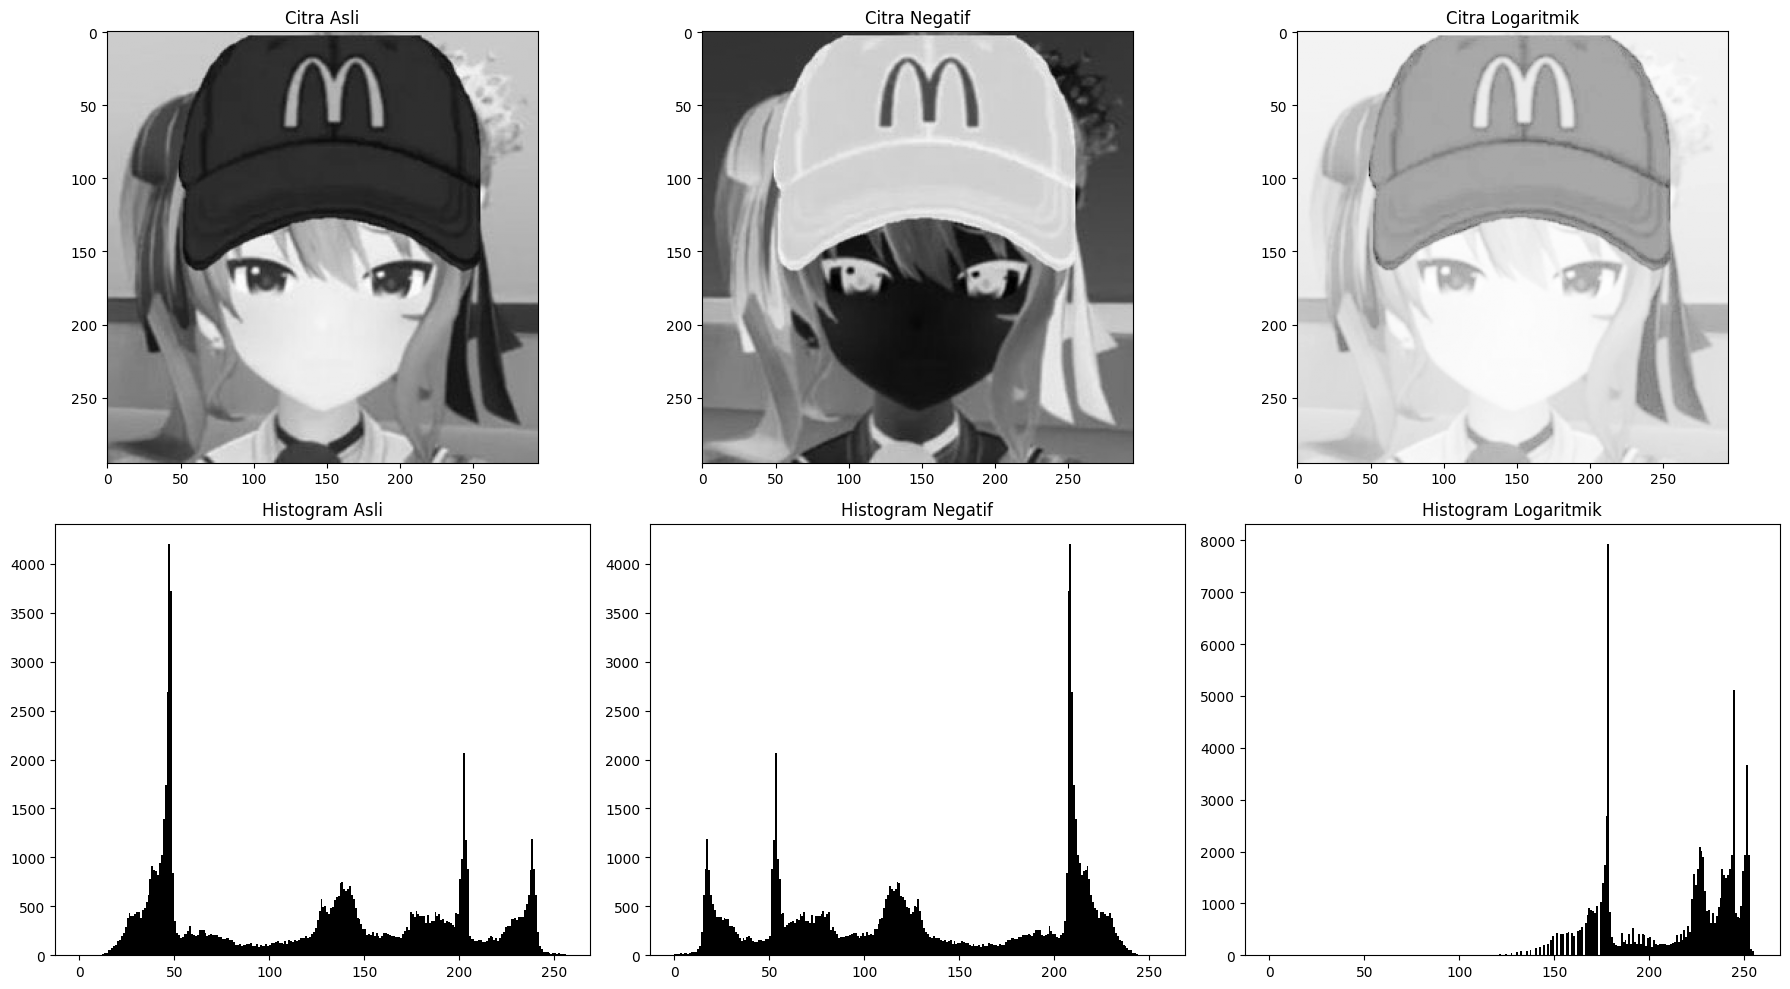

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Membaca citra asli dalam mode grayscale
# Ganti 'image.jpg' dengan nama file yang kamu upload di Google Colab
img_path = 'suisei.jpg'
f = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if f is None:
    print("Error: Citra tidak ditemukan. Pastikan file sudah diupload.")
else:
    # --- TRANSFORMASI NEGATIF ---
    # G = 255 - F
    img_negatif = 255 - f

    # --- TRANSFORMASI LOGARITMIK ---
    # G = c * log(1 + F)
    # Menghitung konstanta c agar output tetap dalam rentang 0-255
    c = 255 / np.log(1 + np.max(f.astype(np.float64)))

    img_log = c * (np.log(1 + f.astype(np.float64)))
    img_log = np.array(img_log, dtype=np.uint8)

    # --- VISUALISASI ---
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))

    # Baris 1: Menampilkan Citra
    axs[0, 0].imshow(f, cmap='gray')
    axs[0, 0].set_title('Citra Asli')

    axs[0, 1].imshow(img_negatif, cmap='gray')
    axs[0, 1].set_title('Citra Negatif')

    axs[0, 2].imshow(img_log, cmap='gray')
    axs[0, 2].set_title('Citra Logaritmik')

    # Baris 2: Menampilkan Histogram
    axs[1, 0].hist(f.ravel(), 256, [0, 256], color='black')
    axs[1, 0].set_title('Histogram Asli')

    axs[1, 1].hist(img_negatif.ravel(), 256, [0, 256], color='black')
    axs[1, 1].set_title('Histogram Negatif')

    axs[1, 2].hist(img_log.ravel(), 256, [0, 256], color='black')
    axs[1, 2].set_title('Histogram Logaritmik')

    plt.tight_layout()
    plt.show()